In [440]:
import seaborn as sns


In [441]:
import matplotlib.pyplot as plt


In [442]:
import numpy as np
import pandas as pd 

df = pd.read_csv('Walmart_Sales.csv')

In [443]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [444]:
df.shape

(6435, 8)

In [445]:
df.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [446]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [447]:
(df == "").sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [448]:
df.duplicated().sum()

np.int64(0)

In [449]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

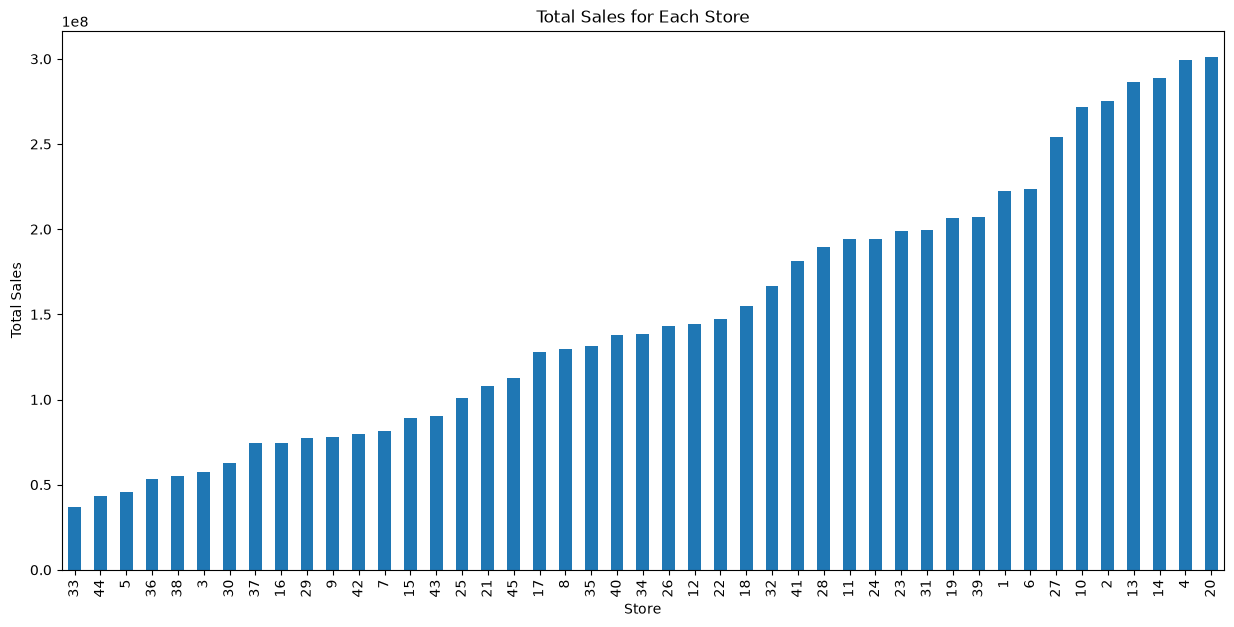

In [450]:
import matplotlib.pyplot as plt

# Total sales by store
sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values()

# Plot
sales.plot(kind='bar', figsize=(15,7))

plt.title("Total Sales for Each Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

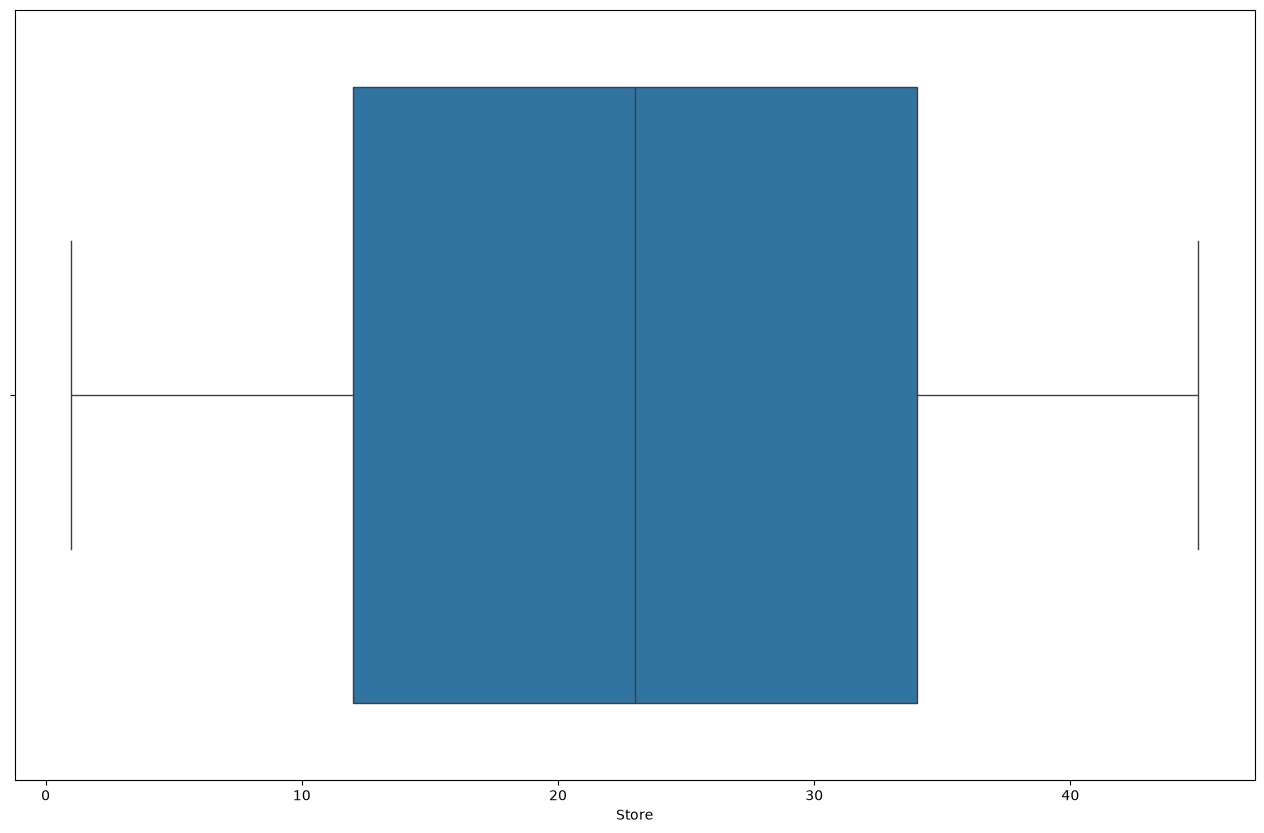

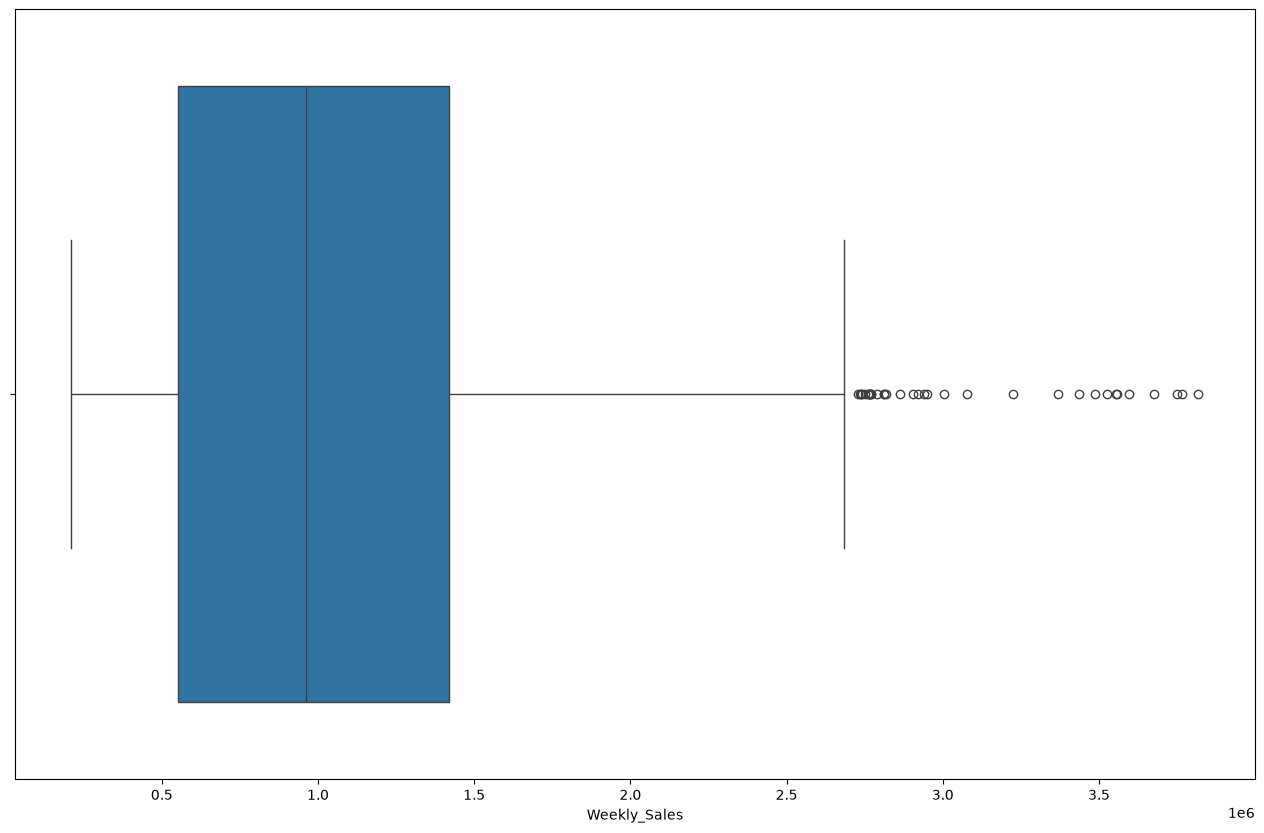

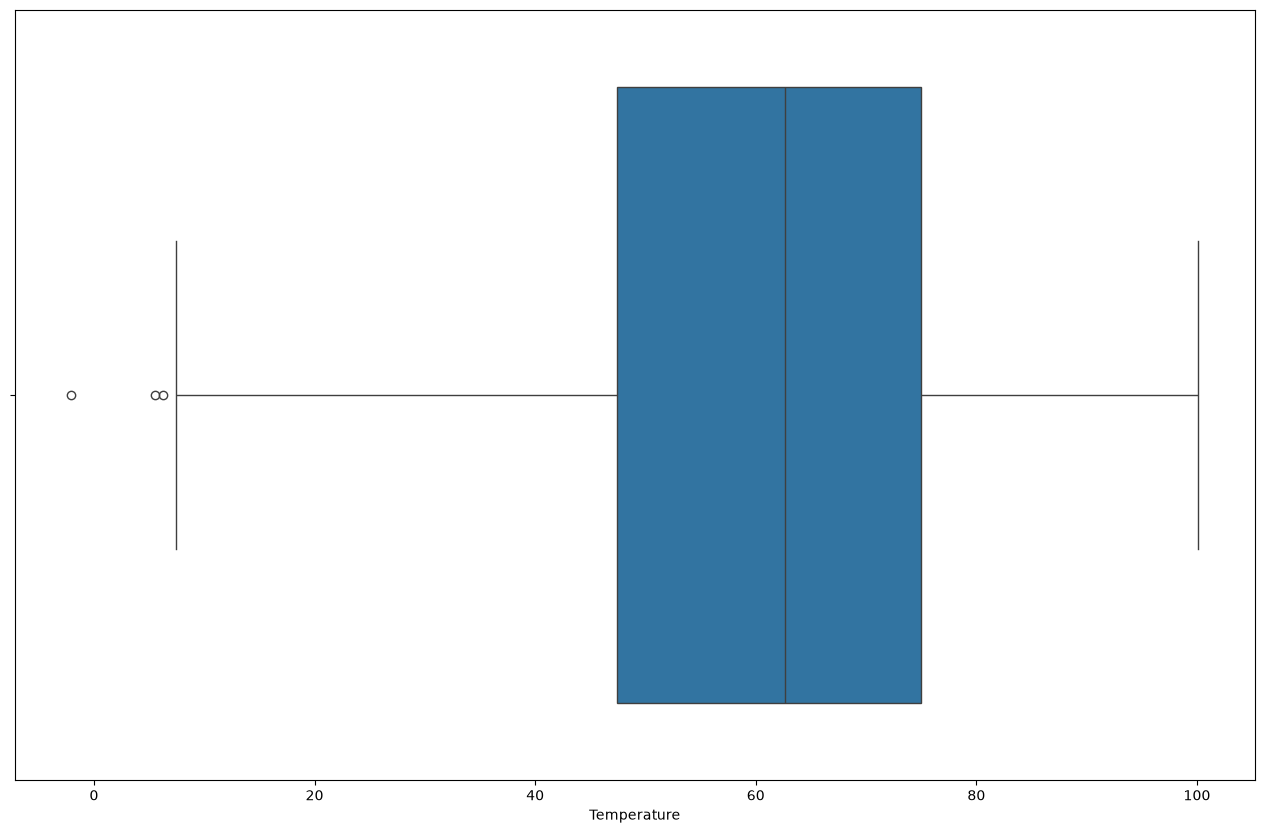

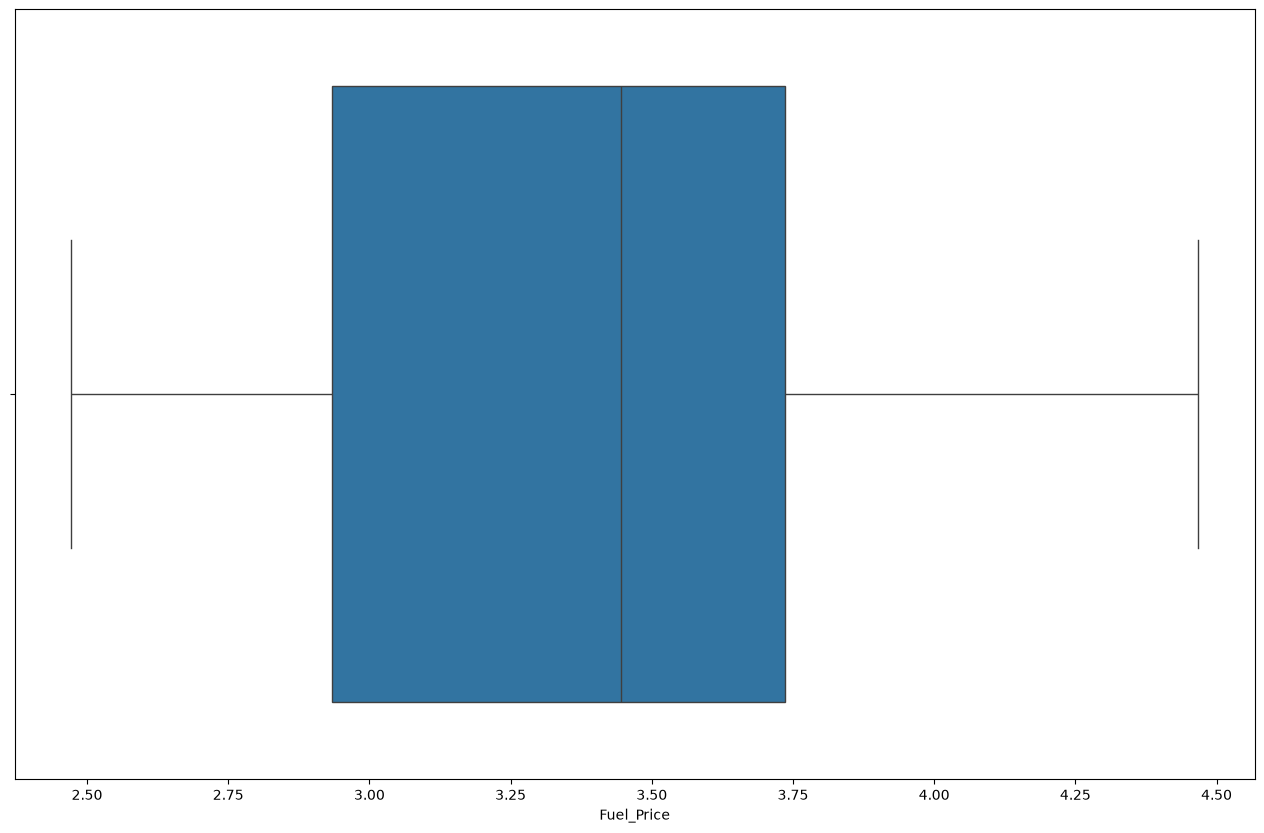

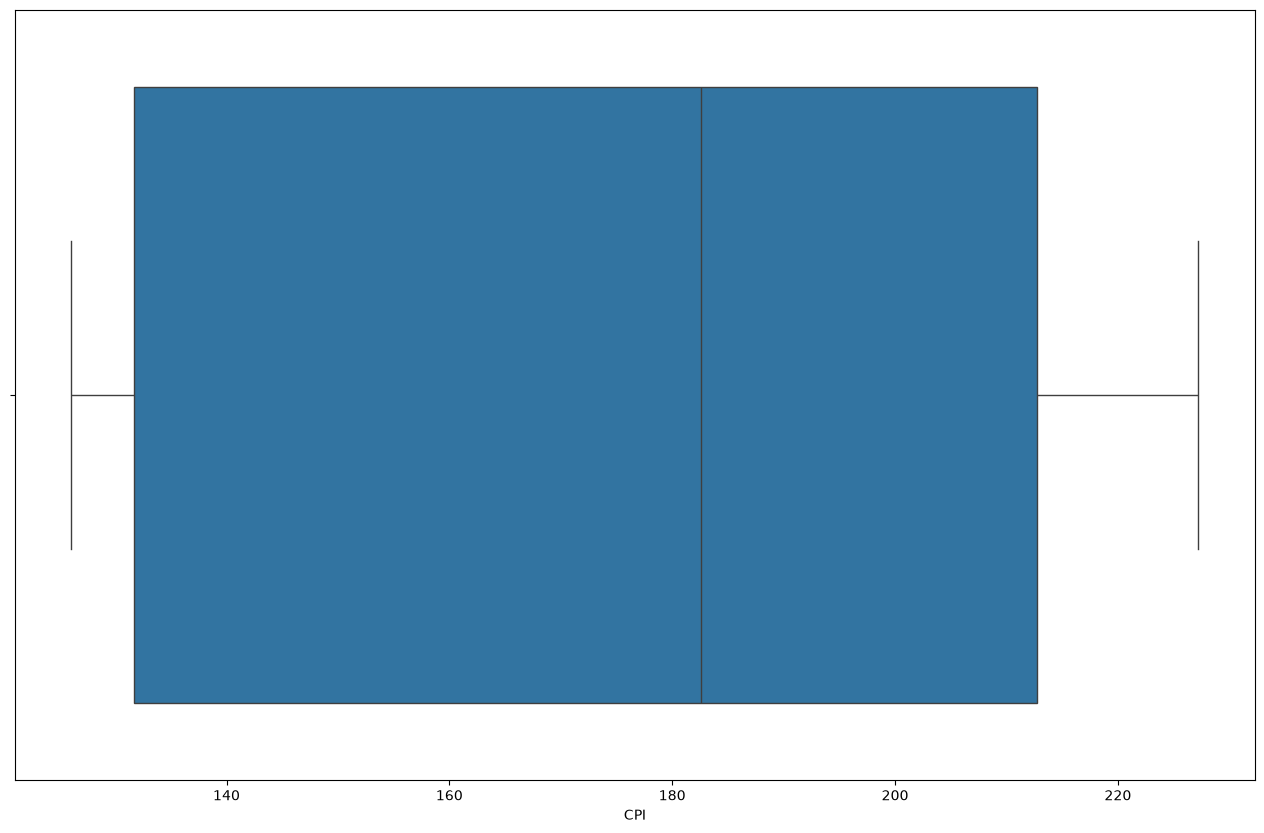

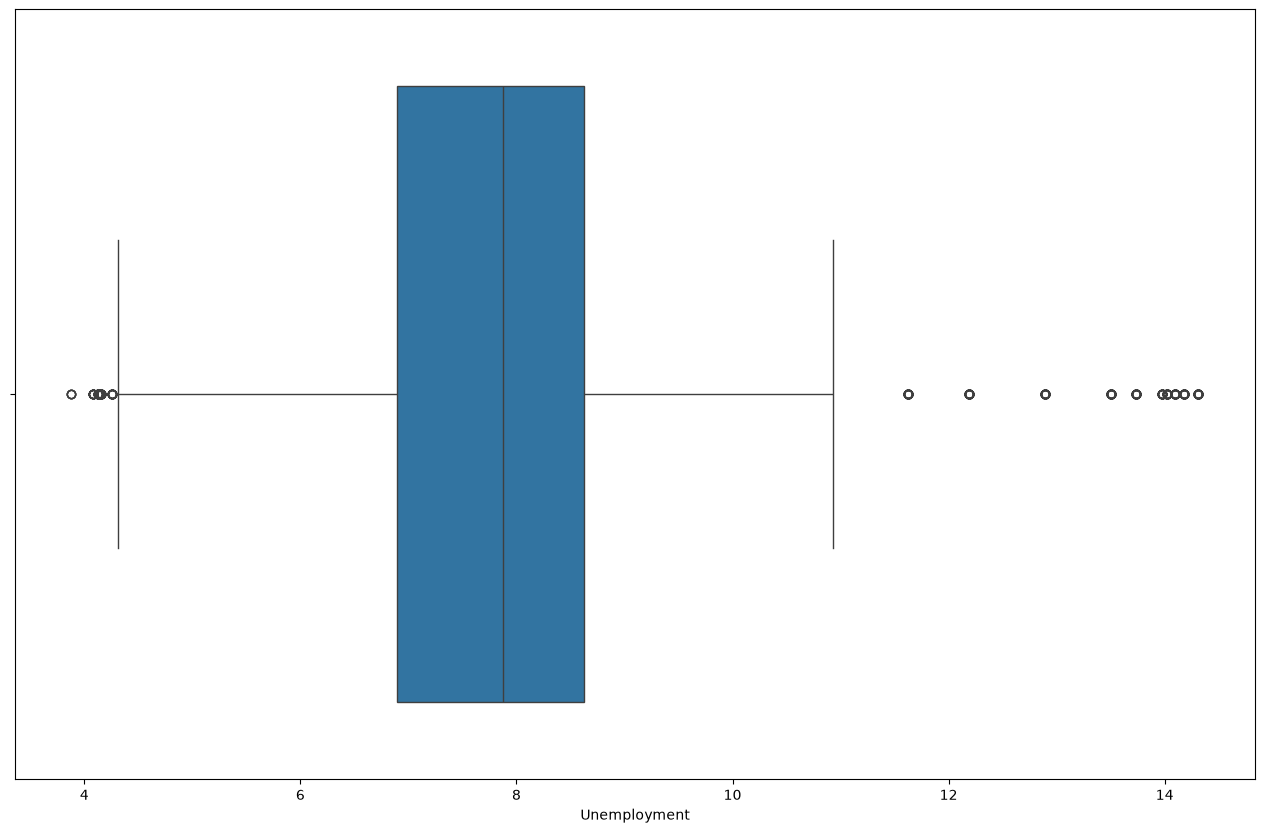

In [451]:
numeric_columns = ['Store', 'Weekly_Sales', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment']
for num_cols in numeric_columns:
     plt.figure(figsize=(16, 10))
     sns.boxplot(x = df[num_cols])

In [452]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

df.drop('Date', axis=1, inplace=True)

In [453]:
# drop the outliers     
df_new = df[(df['Unemployment']<10.9) & (df['Unemployment']>4.7) & (df['Temperature']>13)]
df_new

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,39,3
6431,45,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,40,4
6432,45,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,41,4
6433,45,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,42,4


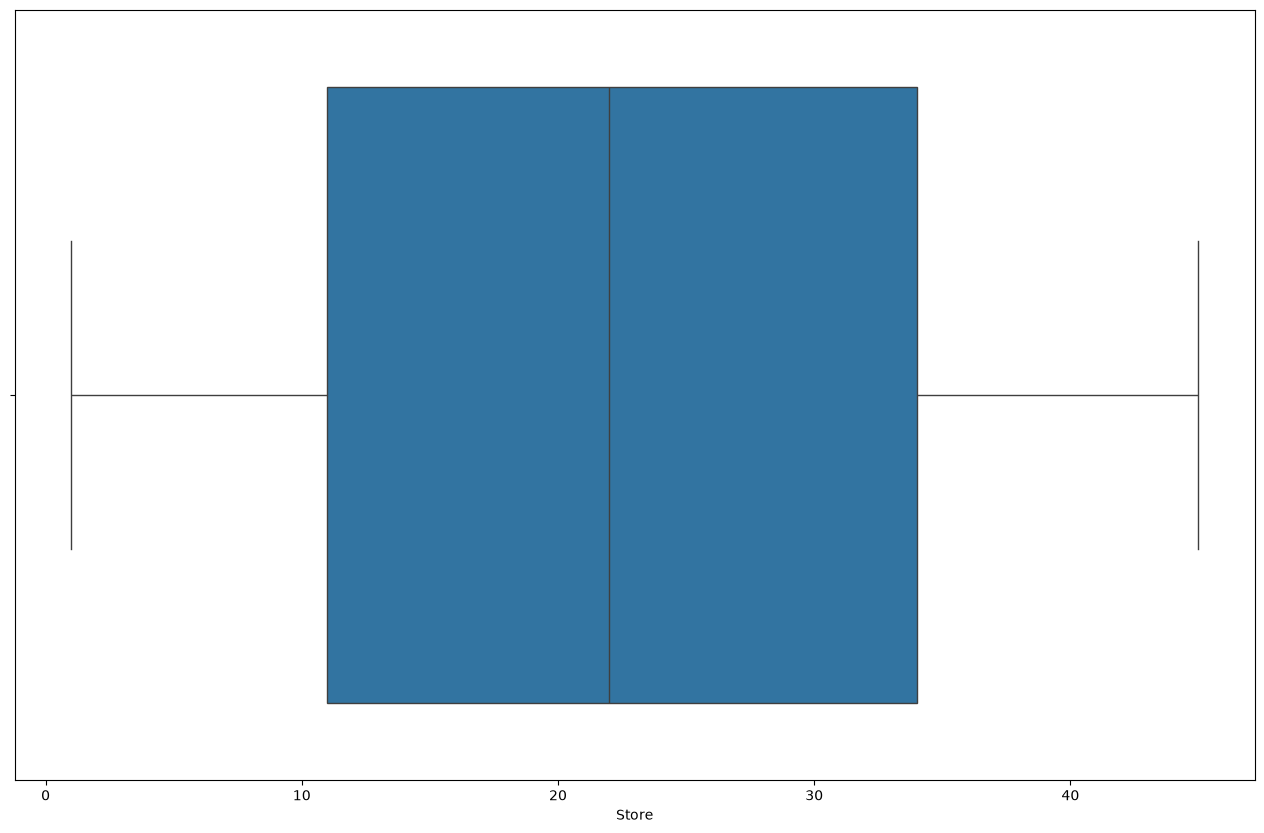

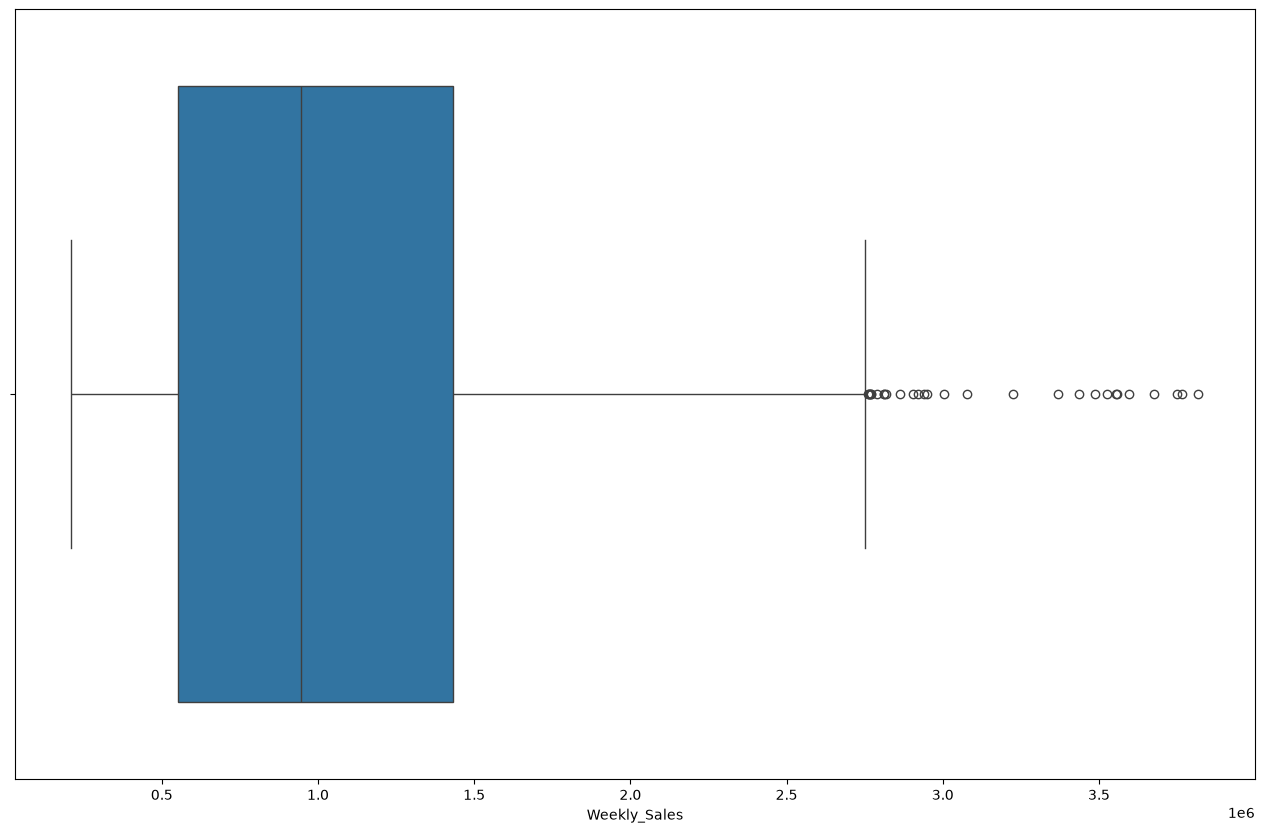

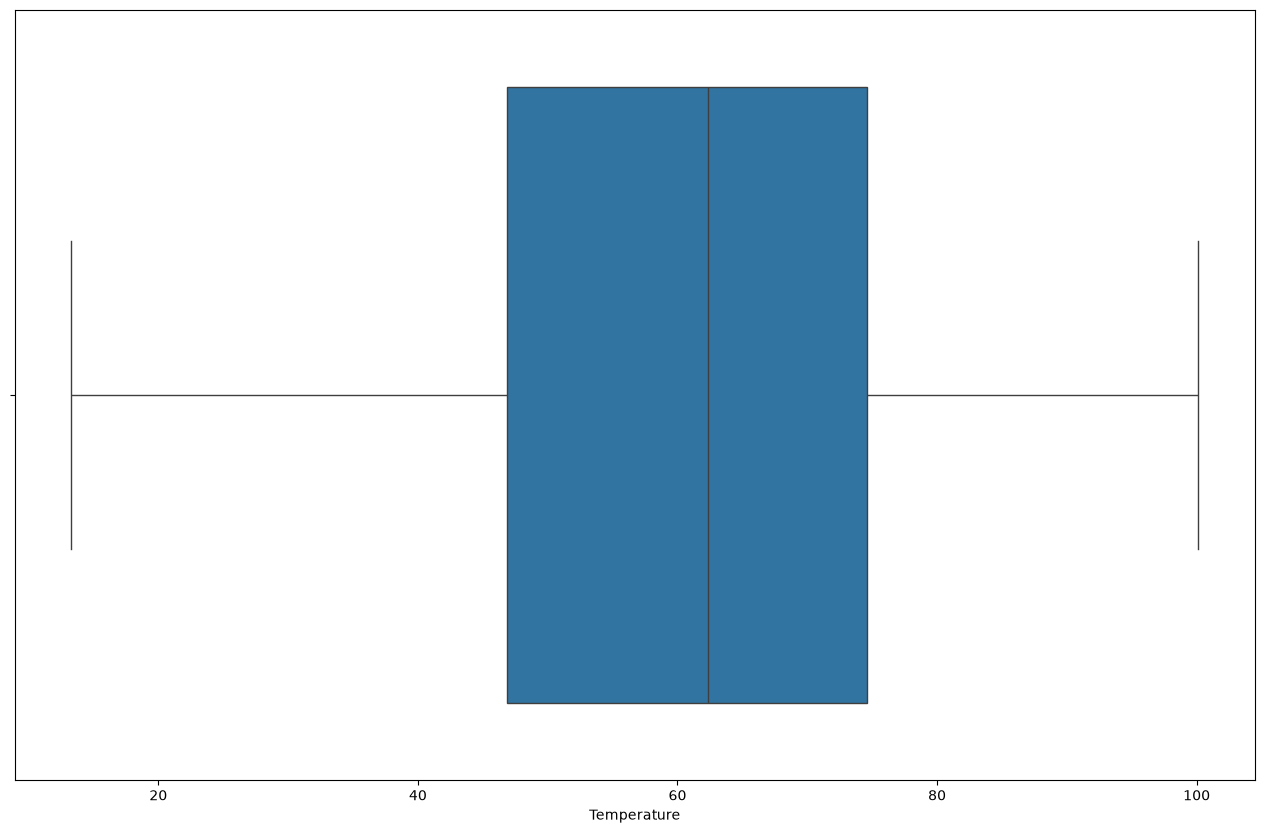

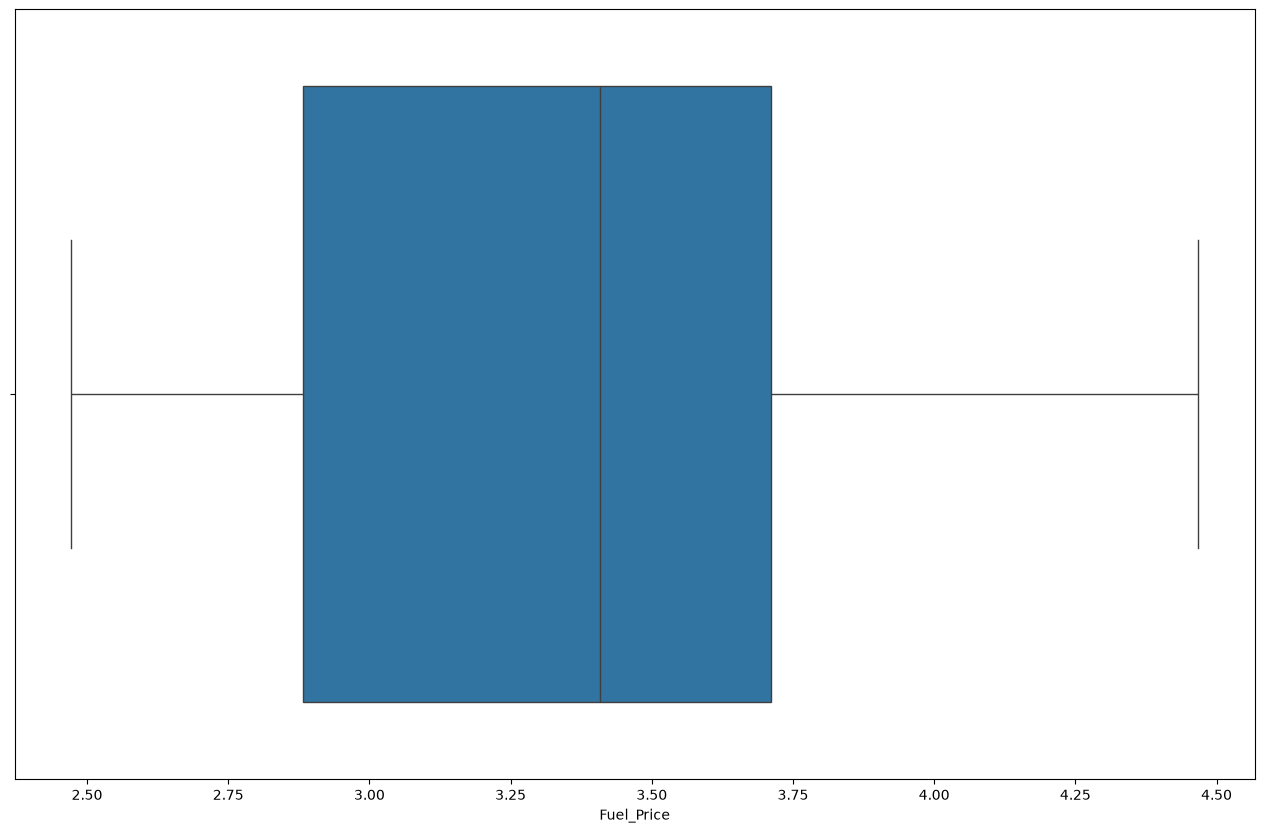

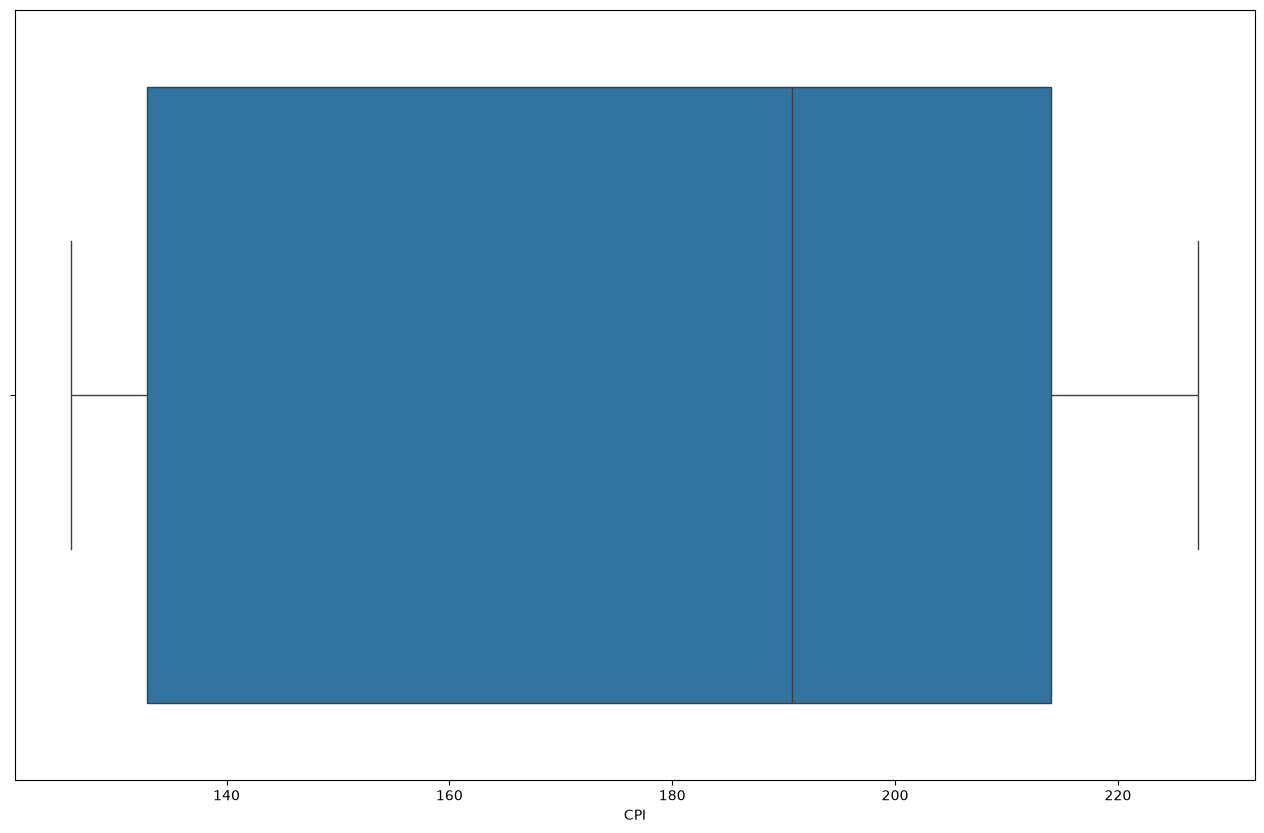

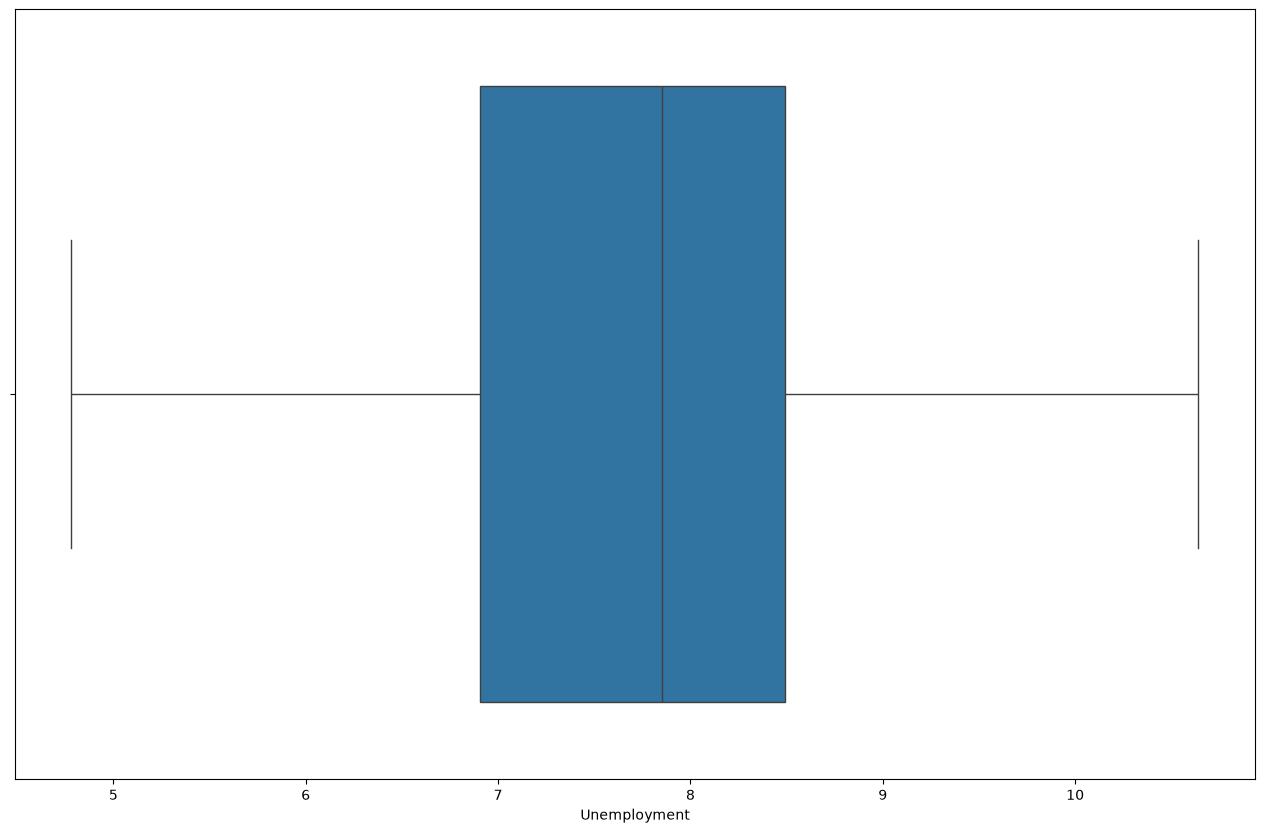

In [454]:
numeric_columns = ['Store', 'Weekly_Sales', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment']
for num_cols in numeric_columns:
     plt.figure(figsize=(16, 10))
     sns.boxplot(x = df_new[num_cols])

In [455]:
df_new.head(4)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1


In [456]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5817 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         5817 non-null   int64  
 1   Weekly_Sales  5817 non-null   float64
 2   Holiday_Flag  5817 non-null   int64  
 3   Temperature   5817 non-null   float64
 4   Fuel_Price    5817 non-null   float64
 5   CPI           5817 non-null   float64
 6   Unemployment  5817 non-null   float64
 7   Year          5817 non-null   int32  
 8   Month         5817 non-null   int32  
 9   Week          5817 non-null   int64  
 10  Quarter       5817 non-null   int32  
dtypes: float64(5), int32(3), int64(3)
memory usage: 477.2 KB


In [457]:
df_new.describe().columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter'],
      dtype='object')

In [458]:
#df_new = df_new.astype(int)

In [459]:
df_new = pd.get_dummies(df_new, columns=['Store'], drop_first=True)


In [460]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [ ]:

X = df_new.drop('Weekly_Sales' , axis=1)
y = df_new['Weekly_Sales']

In [462]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [463]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [464]:
LinearModal = LinearRegression()

In [465]:
LinearModal.fit(X_train_scaled , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](53,)","[ 5418.91, -35336.19, 4335.5 ,...,-117551.93,-138096.54, -94969.41]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.045e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,53
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,53
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](53,)","[120.29,103.36, 94.77,..., 12.97, 4.24, 1.19]"


In [466]:
y_pred = LinearModal.predict(X_test_scaled)


In [467]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [468]:
n = len(y_test)
p = X_test_scaled.shape[1]

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

In [469]:
# Print results
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Adjusted R²:", adj_r2)

MAE : 91751.5499748381
MSE : 20396423041.846943
RMSE: 142816.046163752
R² Score: 0.9345695981152558
Adjusted R²: 0.9314454437910292
